In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import seaborn as sns
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

In [2]:
#train_metadata = pd.read_csv('ISIC_2019_Training_Metadata.csv')
train_metadata = pd.read_csv("challenge-2019-training_metadata.csv", 
                                               usecols = ['isic_id', 'attribution', 'age_approx', 'anatom_site_general', 'sex'])
train_groundtruth = pd.read_csv('ISIC_2019_Training_GroundTruth.csv')
#test_metadata = pd.read_csv('ISIC_2019_Test_Metadata.csv')
test_metadata = pd.read_csv("challenge-2019-test_metadata.csv", 
                                               usecols = ['isic_id', 'attribution', 'age_approx', 'anatom_site_general', 'sex'])
test_groundtruth = pd.read_csv('ISIC_2019_Test_GroundTruth.csv')

In [3]:
train_metadata

,isic_id,attribution,age_approx,anatom_site_general,sex
0,ISIC_0000000,Anonymous,55.0,anterior torso,female
1,ISIC_0000001,Anonymous,30.0,anterior torso,female
2,ISIC_0000002,Anonymous,60.0,upper extremity,female
3,ISIC_0000003,Anonymous,30.0,upper extremity,male
4,ISIC_0000004,Anonymous,80.0,posterior torso,male
...,...,...,...,...,...
25326,ISIC_0073247,Hospital Clínic de Barcelona,85.0,head/neck,female
25327,ISIC_0073248,Hospital Clínic de Barcelona,65.0,anterior torso,male
25328,ISIC_0073249,Hospital Clínic de Barcelona,70.0,lower extremity,male
25329,ISIC_0073251,Hospital Clínic de Barcelona,55.0,palms/soles,female


In [4]:
train_groundtruth

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
25326,ISIC_0073247,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
25327,ISIC_0073248,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
25328,ISIC_0073249,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25329,ISIC_0073251,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
test_metadata.head()

,isic_id,attribution,age_approx,anatom_site_general,sex
0,ISIC_0034321,"ViDIR Group, Department of Dermatology, Medica...",60.0,NaN,female
1,ISIC_0034322,"ViDIR Group, Department of Dermatology, Medica...",70.0,anterior torso,male
2,ISIC_0034323,"ViDIR Group, Department of Dermatology, Medica...",70.0,lower extremity,male
3,ISIC_0034324,"ViDIR Group, Department of Dermatology, Medica...",70.0,lower extremity,male
4,ISIC_0034325,"ViDIR Group, Department of Dermatology, Medica...",30.0,upper extremity,female


In [6]:
CLASS_NAMES = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"]
#CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

In [7]:
def process_data(metadata, groundtruth):
    groundtruth['image'] = groundtruth['image'].str.replace('_downsampled', '', regex=False)
    df = pd.merge(metadata, groundtruth, how = "inner", left_on='isic_id', right_on='image')
    
    # Drop UNK rows — these have all 8 class columns equal to 0.
    # Using idxmax or argmax on these rows silently assigns them to
    # the first class (MEL), which is incorrect.
    valid_mask = df[CLASS_NAMES].sum(axis=1) == 1
    n_dropped = (~valid_mask).sum()
    if n_dropped > 0:
        print(f"Dropping {n_dropped} rows with no valid class label (UNK).")
    df = df[valid_mask].reset_index(drop=True)

    # Now safe to use idxmax — every remaining row has exactly one 1
    df['class'] = df[CLASS_NAMES].idxmax(axis=1)

    bins   = [0, 30, 45, 60, 75, 200]
    labels = ['[0, 30)', '[30, 45)', '[45, 60)', '[60, 75)', '75+']
    df['age_group'] = pd.cut(df['age_approx'], bins=bins, labels=labels, right=False)

    return df

In [8]:
train_df = process_data(train_metadata, train_groundtruth)
test_df = process_data(test_metadata, test_groundtruth)

Dropping 2047 rows with no valid class label (UNK).


In [9]:
train_df

,isic_id,attribution,age_approx,anatom_site_general,sex,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK,class,age_group
0,ISIC_0000000,Anonymous,55.0,anterior torso,female,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NV,"[45, 60)"
1,ISIC_0000001,Anonymous,30.0,anterior torso,female,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NV,"[30, 45)"
2,ISIC_0000002,Anonymous,60.0,upper extremity,female,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL,"[60, 75)"
3,ISIC_0000003,Anonymous,30.0,upper extremity,male,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NV,"[30, 45)"
4,ISIC_0000004,Anonymous,80.0,posterior torso,male,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL,75+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25326,ISIC_0073247,Hospital Clínic de Barcelona,85.0,head/neck,female,ISIC_0073247,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,BCC,75+
25327,ISIC_0073248,Hospital Clínic de Barcelona,65.0,anterior torso,male,ISIC_0073248,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,BKL,"[60, 75)"
25328,ISIC_0073249,Hospital Clínic de Barcelona,70.0,lower extremity,male,ISIC_0073249,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL,"[60, 75)"
25329,ISIC_0073251,Hospital Clínic de Barcelona,55.0,palms/soles,female,ISIC_0073251,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NV,"[45, 60)"


In [10]:
test_df

,isic_id,attribution,age_approx,anatom_site_general,sex,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK,score_weight,validation_weight,class,age_group
0,ISIC_0034321,"ViDIR Group, Department of Dermatology, Medica...",60.0,NaN,female,ISIC_0034321,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NV,"[60, 75)"
1,ISIC_0034322,"ViDIR Group, Department of Dermatology, Medica...",70.0,anterior torso,male,ISIC_0034322,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NV,"[60, 75)"
2,ISIC_0034323,"ViDIR Group, Department of Dermatology, Medica...",70.0,lower extremity,male,ISIC_0034323,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,BCC,"[60, 75)"
3,ISIC_0034324,"ViDIR Group, Department of Dermatology, Medica...",70.0,lower extremity,male,ISIC_0034324,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NV,"[60, 75)"
4,ISIC_0034325,"ViDIR Group, Department of Dermatology, Medica...",30.0,upper extremity,female,ISIC_0034325,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NV,"[30, 45)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6186,ISIC_0073226,Hospital Clínic de Barcelona,50.0,lower extremity,male,ISIC_0073226,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,BCC,"[45, 60)"
6187,ISIC_0073234,Hospital Clínic de Barcelona,70.0,anterior torso,female,ISIC_0073234,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NV,"[60, 75)"
6188,ISIC_0073236,Hospital Clínic de Barcelona,75.0,anterior torso,male,ISIC_0073236,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,SCC,75+
6189,ISIC_0073243,Hospital Clínic de Barcelona,65.0,lower extremity,male,ISIC_0073243,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,BCC,"[60, 75)"


In [11]:
def print_metadata_completion(df, name):
    cols = ['age_approx', 'sex', 'anatom_site_general']
    existing_cols = [c for c in cols if c in df.columns]

    complete_rows = df[existing_cols].notna().all(axis=1).sum()
    total_rows = len(df)
    fraction = (complete_rows / total_rows) * 100

    print(f"--- {name} Metadata Integrity ---")
    print(f"Complete records (Age + Sex + Site): {complete_rows} / {total_rows}")
    print(f"Fraction fully populated: {fraction:.2f}%")
    print("-" * 30)

print_metadata_completion(train_df, "Training Set") ## need to check distribution if we exclude incomplete samples
print_metadata_completion(test_df, "Test Set")

--- Training Set Metadata Integrity ---
Complete records (Age + Sex + Site): 22484 / 25331
Fraction fully populated: 88.76%
------------------------------
--- Test Set Metadata Integrity ---
Complete records (Age + Sex + Site): 5541 / 6191
Fraction fully populated: 89.50%
------------------------------


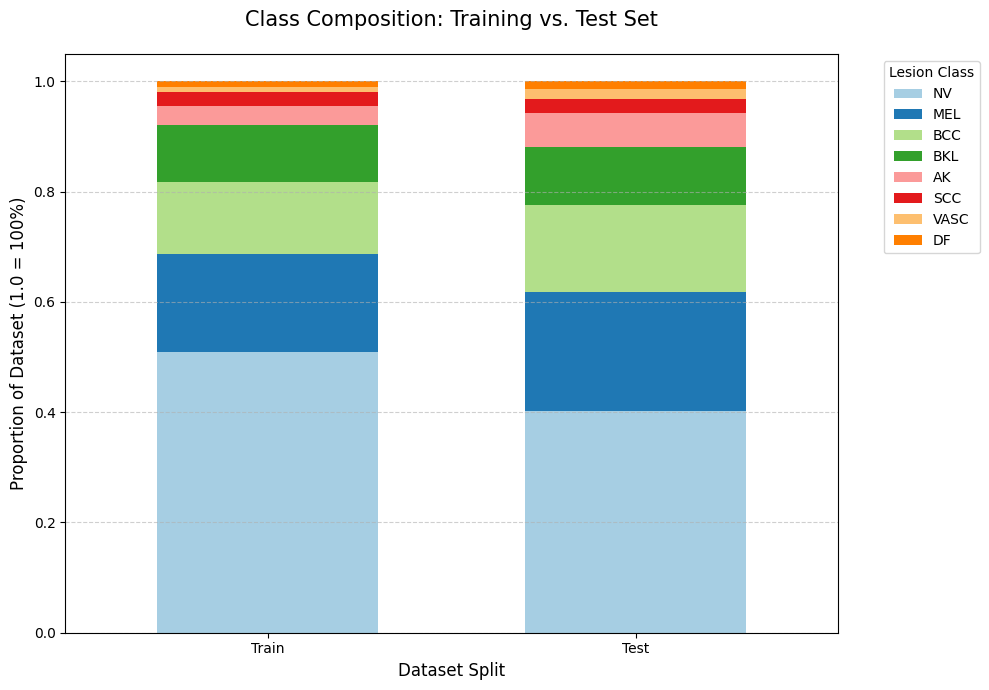

In [12]:
train_counts = train_df['class'].value_counts()
test_counts = test_df['class'].value_counts()

class_dist = pd.DataFrame({'Train': train_counts, 'Test': test_counts}).fillna(0)
class_dist_t = class_dist.T
class_props = class_dist_t.div(class_dist_t.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("Paired", 8)
class_props.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.6)

ax.set_title('Class Composition: Training vs. Test Set', fontsize=15, pad=20)
ax.set_ylabel('Proportion of Dataset (1.0 = 100%)', fontsize=12)
ax.set_xlabel('Dataset Split', fontsize=12)
plt.xticks(rotation=0)

ax.legend(title='Lesion Class', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show() ## train and test have relatively similar distribution of classes except for MEL and NV

In [13]:
sex_train = pd.crosstab(train_df['class'], train_df['sex'], normalize='index')
age_train = pd.crosstab(train_df['class'], train_df['age_group'], normalize='index')

sex_test = pd.crosstab(test_df['class'], train_df['sex'], normalize='index')
age_test = pd.crosstab(test_df['class'], train_df['age_group'], normalize='index')

In [14]:
sex_comparison = pd.concat([sex_train, sex_test], axis=1, keys=['Train', 'Test']).fillna(0)
print(sex_comparison)

          Train                Test          
sex      female      male    female      male
class                                        
AK     0.469907  0.530093  0.436314  0.563686
BCC    0.397046  0.602954  0.481211  0.518789
BKL    0.435986  0.564014  0.479100  0.520900
DF     0.489540  0.510460  0.556818  0.443182
MEL    0.445846  0.554154  0.459938  0.540062
NV     0.506109  0.493891  0.467521  0.532479
SCC    0.323248  0.676752  0.391026  0.608974
VASC   0.494071  0.505929  0.432990  0.567010


In [15]:
age_comparison = pd.concat([age_train, age_test], axis=1, keys=['Train', 'Test'])
print(age_comparison)

              Train                                              Test  \
age_group   [0, 30)  [30, 45)  [45, 60)  [60, 75)       75+   [0, 30)   
class                                                                   
AK         0.002315  0.039352  0.140046  0.458333  0.359954  0.063187   
BCC        0.008140  0.072656  0.199578  0.337052  0.382575  0.081309   
BKL        0.005013  0.089472  0.217123  0.372156  0.316236  0.128039   
DF         0.037657  0.259414  0.372385  0.234310  0.096234  0.093023   
MEL        0.015776  0.120802  0.279017  0.328600  0.255803  0.075781   
NV         0.124740  0.314247  0.353378  0.155406  0.052228  0.128559   
SCC        0.000000  0.012739  0.117834  0.378981  0.490446  0.117647   
VASC       0.084337  0.192771  0.289157  0.216867  0.216867  0.166667   

                                                   
age_group  [30, 45)  [45, 60)  [60, 75)       75+  
class                                              
AK         0.236264  0.277473  0.233516 

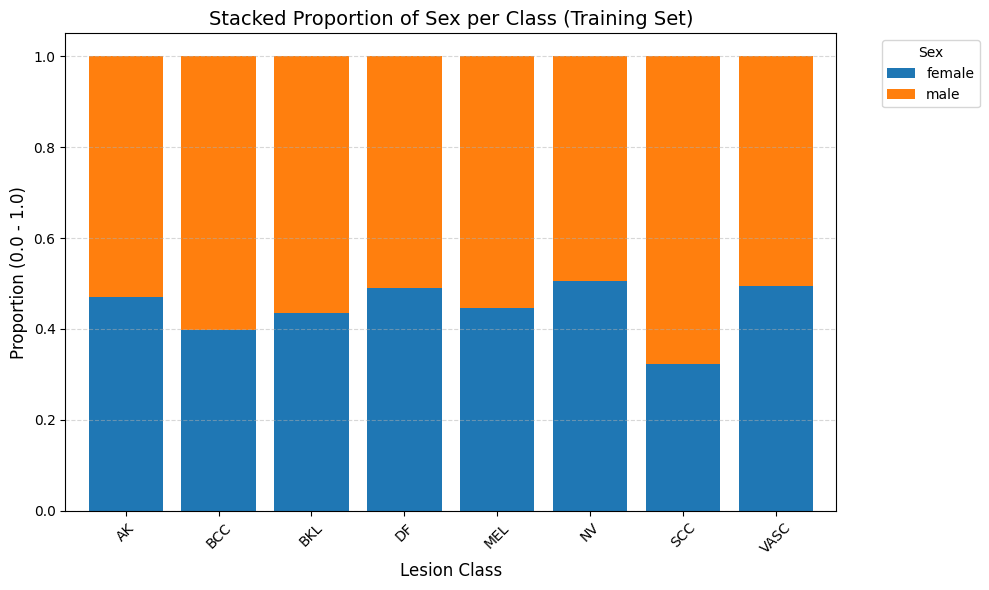

In [16]:
ax = sex_train.plot(kind='bar', stacked=True, figsize=(10, 6), width=0.8)

plt.title('Stacked Proportion of Sex per Class (Training Set)', fontsize=14)
plt.xlabel('Lesion Class', fontsize=12)
plt.ylabel('Proportion (0.0 - 1.0)', fontsize=12)
plt.xticks(rotation=45)

plt.legend(title='Sex', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

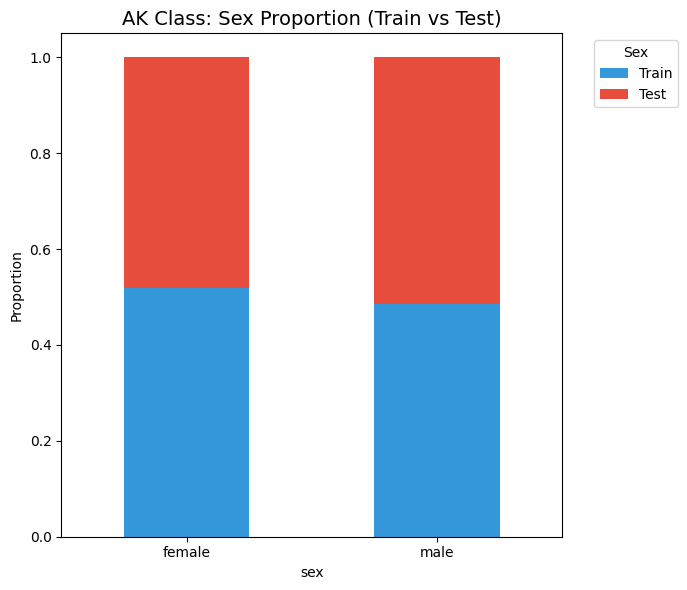

In [17]:
ak_data = sex_comparison.loc['AK']
ak_df = ak_data.unstack(level=0) 

ak_proportions = ak_df.div(ak_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 6))
ak_proportions.plot(kind='bar', stacked=True, ax=ax, color=['#3498db', '#e74c3c'])

ax.set_title('AK Class: Sex Proportion (Train vs Test)', fontsize=14)
ax.set_ylabel('Proportion')
plt.xticks(rotation=0)
ax.legend(title='Sex', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

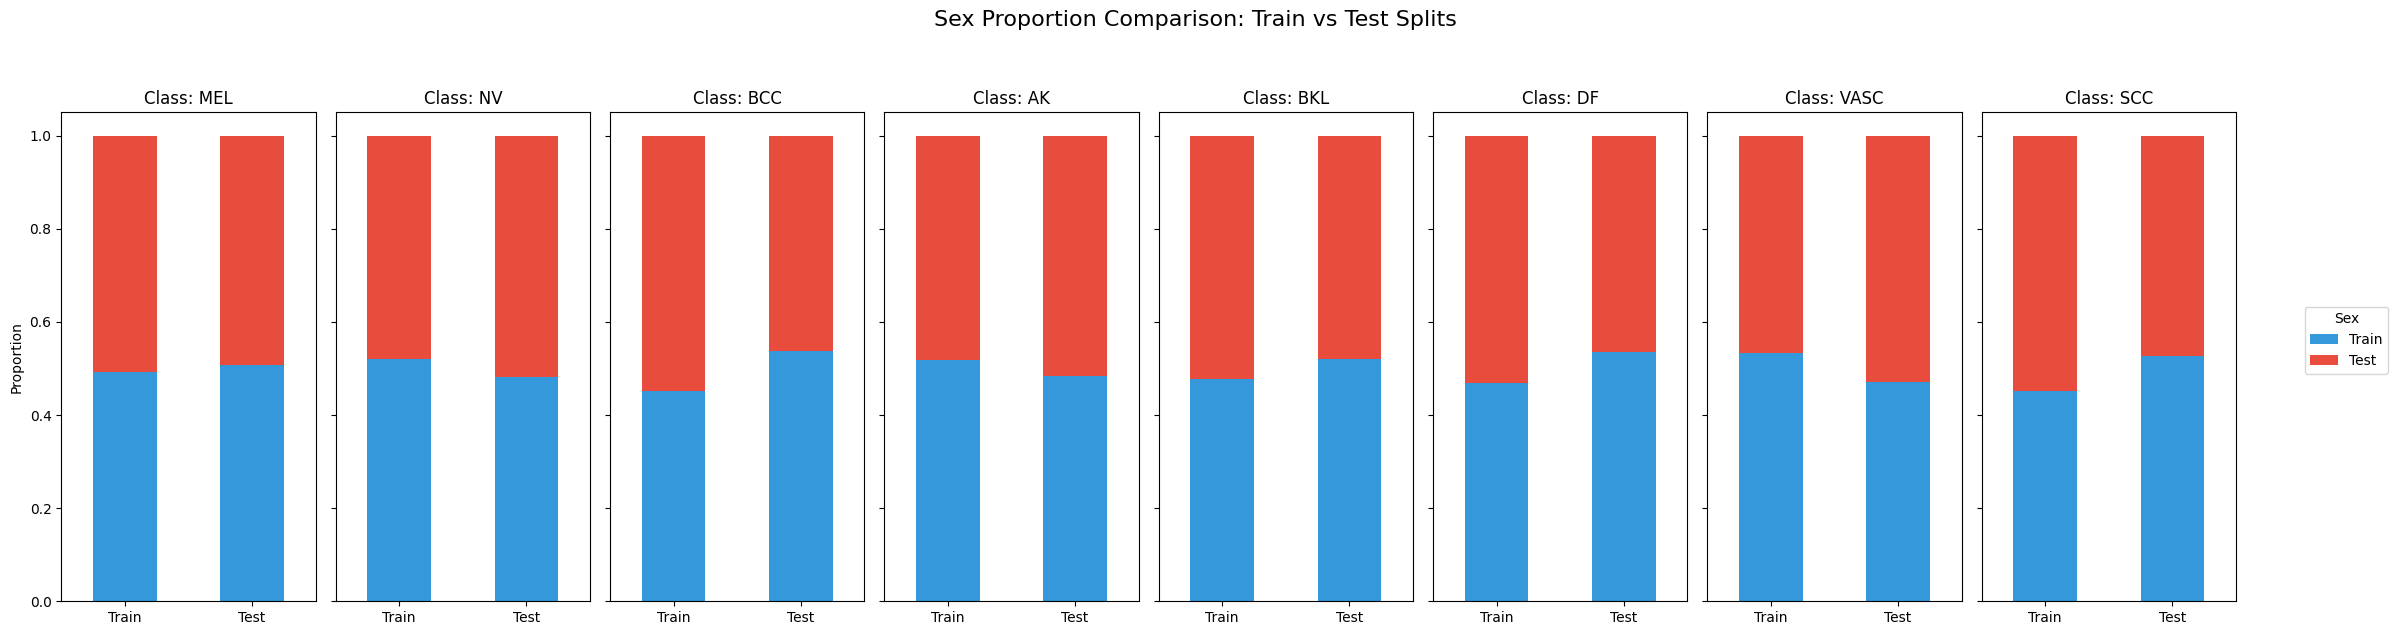

In [18]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(24, 6), sharey=True)

for i, cls in enumerate(CLASS_NAMES):
    try:
        class_df = sex_comparison.loc[cls].unstack(level=0)
        class_props = class_df.div(class_df.sum(axis=1), axis=0)

        class_props.plot(kind='bar', stacked=True, ax=axes[i], color=['#3498db', '#e74c3c'], legend=False)
        
        axes[i].set_title(f'Class: {cls}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_xticklabels(['Train', 'Test'], rotation=0)
        
        if i == 0:
            axes[i].set_ylabel('Proportion')

    except KeyError:
        axes[i].set_title(f'{cls} (N/A)')
        axes[i].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Sex', loc='center right', bbox_to_anchor=(1.0, 0.5))

plt.suptitle('Sex Proportion Comparison: Train vs Test Splits', fontsize=16, y=1.05)
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.show() ## similar distribution of genders in the train and test data by class

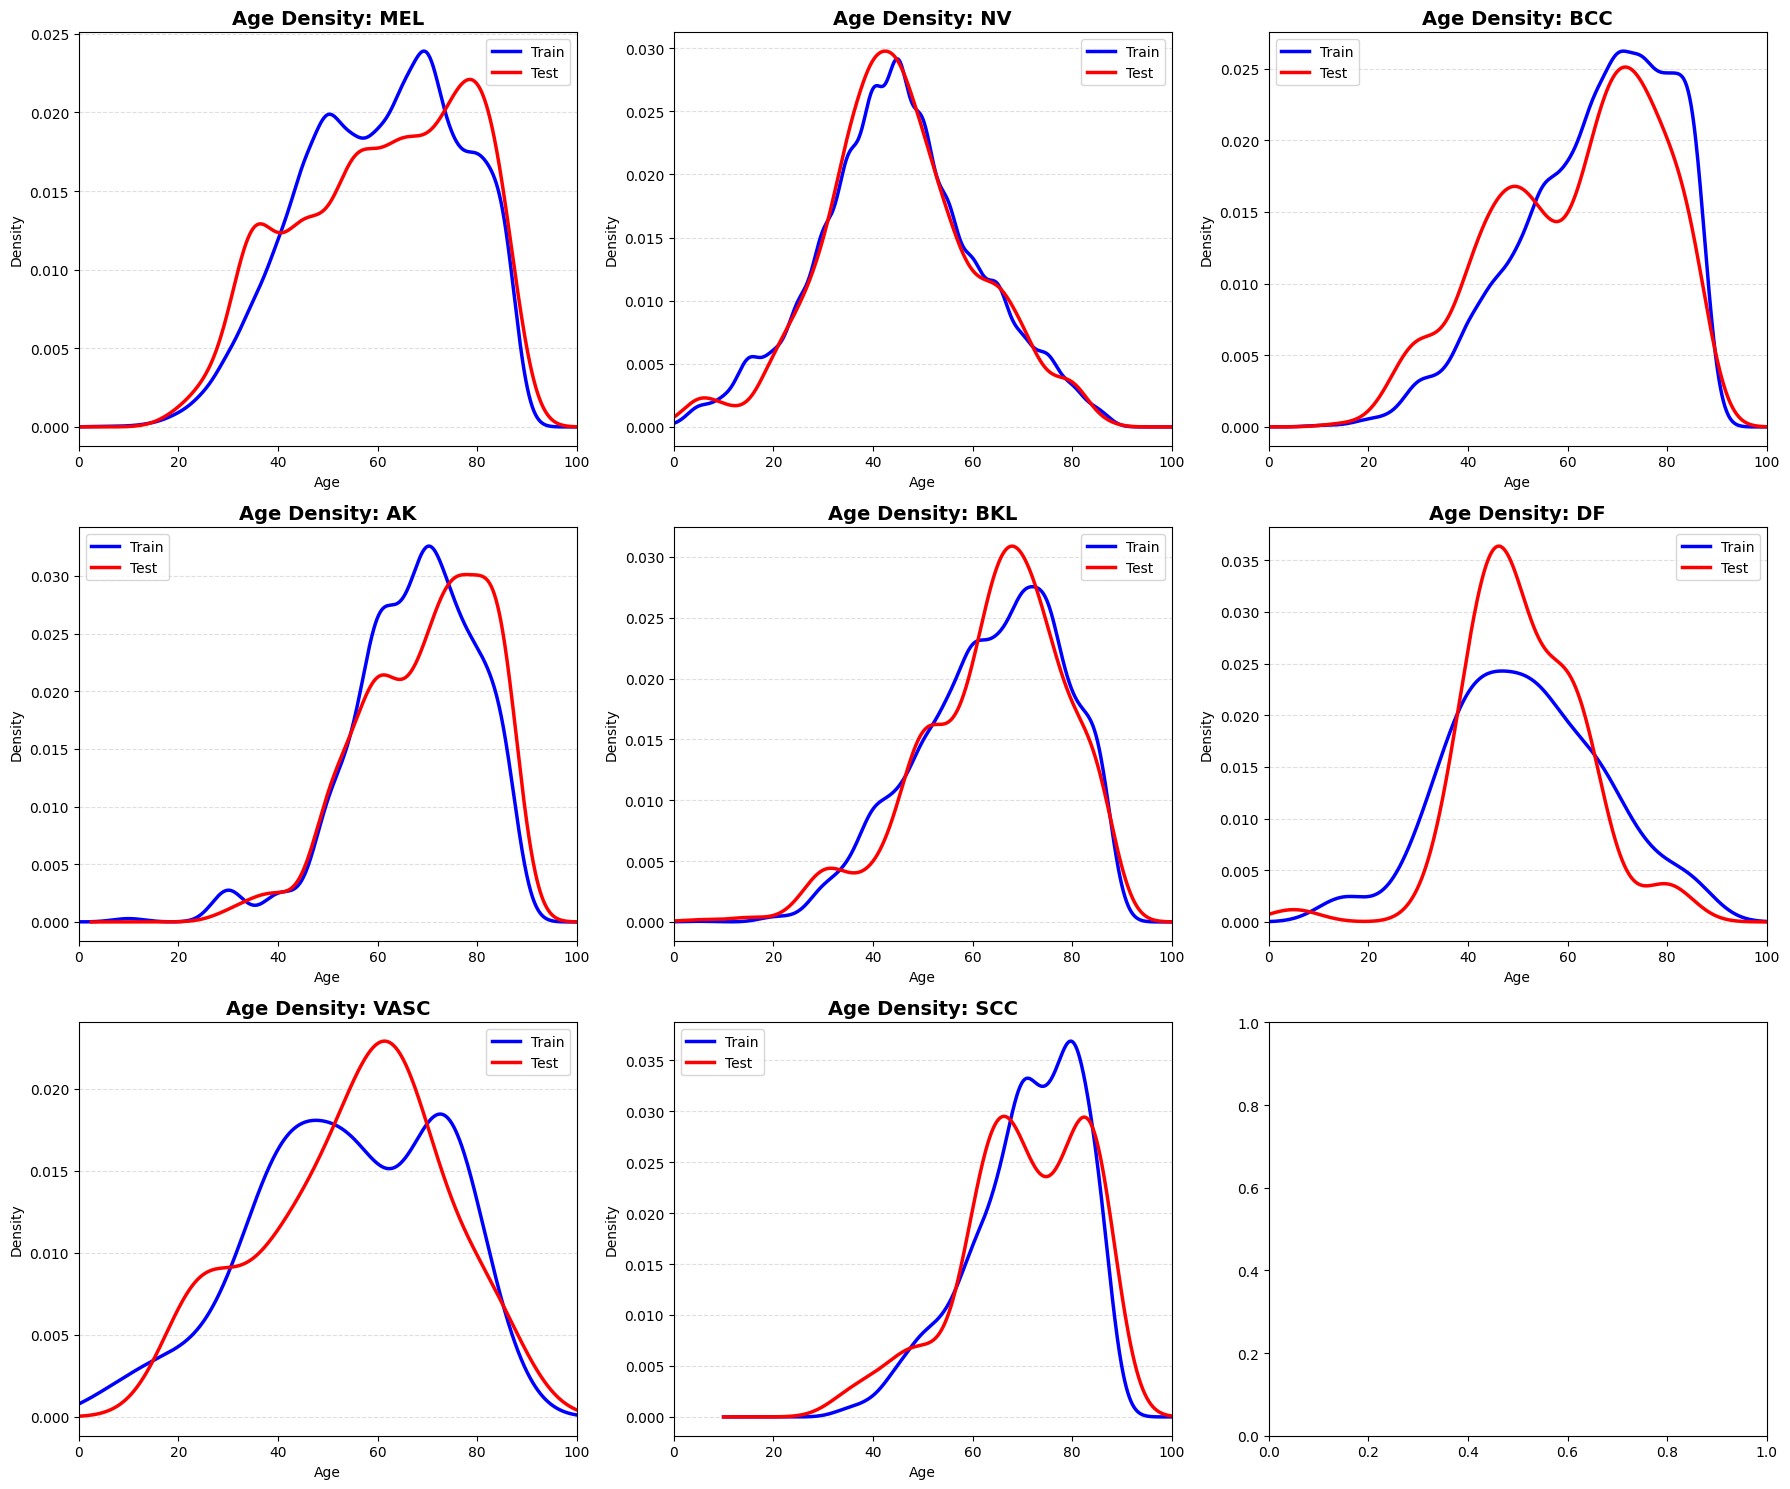

In [19]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    ax = axes[i]
    
    train_ages = train_df[train_df['class'] == cls]['age_approx'].dropna()
    test_ages = test_df[test_df['class'] == cls]['age_approx'].dropna()
    
    if not train_ages.empty:
        train_ages.plot.kde(ax=ax, label='Train', color='blue', linewidth=2.5)
    
    if not test_ages.empty:
        test_ages.plot.kde(ax=ax, label='Test', color='red', linewidth=2.5)
    
    # Formatting
    ax.set_title(f'Age Density: {cls}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Age')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 100) 
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout() ## MEL, AK, DF, VASC, and SCC all have somewhat different age distributions across the data

### Assess missing metadata across data sources

Checking for metadata missingness rate across the 3 source datasets

In [20]:
def analyze_missingness(df, attribution_col='attribution', 
                        target_cols=['age_approx', 'anatom_site_general', 'sex']):
    """
    Analyze missing values in target columns and correlate with attribution dataset.
    
    Parameters:
        df (pd.DataFrame): Input dataframe
        attribution_col (str): Column name for the attribution/dataset identifier
        target_cols (list): Columns to check for missingness
    
    Returns:
        dict: Summary stats and per-attribution breakdown
    """
    results = {}

    # --- 1. Overall missingness ---
    overall = {}
    for col in target_cols:
        if col in df.columns:
            n_missing = df[col].isna().sum()
            pct_missing = n_missing / len(df) * 100
            overall[col] = {'n_missing': n_missing, 'pct_missing': round(pct_missing, 2)}
    results['overall'] = overall

    # --- 2. Per-attribution missingness ---
    if attribution_col not in df.columns:
        raise ValueError(f"Column '{attribution_col}' not found in dataframe.")

    per_attribution = {}
    for attr, group in df.groupby(attribution_col):
        attr_stats = {'n_rows': len(group)}
        for col in target_cols:
            if col in df.columns:
                n_missing = group[col].isna().sum()
                pct_missing = n_missing / len(group) * 100
                attr_stats[f'{col}_missing'] = n_missing
                attr_stats[f'{col}_pct_missing'] = round(pct_missing, 2)
        per_attribution[attr] = attr_stats
    results['per_attribution'] = per_attribution

    # --- 3. Any-field missingness per attribution ---
    df['_any_missing'] = df[target_cols].isna().any(axis=1)
    any_missing_summary = (
        df.groupby(attribution_col)['_any_missing']
        .agg(n_missing='sum', total='count')
        .assign(pct_any_missing=lambda x: round(x['n_missing'] / x['total'] * 100, 2))
    )
    df.drop(columns=['_any_missing'], inplace=True)
    results['any_missing_by_attribution'] = any_missing_summary

    return results


def print_missingness_report(results):
    """Pretty-print the missingness analysis results."""

    print("=" * 60)
    print("OVERALL MISSINGNESS")
    print("=" * 60)
    for col, stats in results['overall'].items():
        print(f"  {col}: {stats['n_missing']} missing ({stats['pct_missing']}%)")

    print("\n" + "=" * 60)
    print("MISSINGNESS BY ATTRIBUTION")
    print("=" * 60)
    per_attr = pd.DataFrame(results['per_attribution']).T
    print(per_attr.to_string())

    print("\n" + "=" * 60)
    print("ANY-FIELD MISSINGNESS BY ATTRIBUTION")
    print("=" * 60)
    print(results['any_missing_by_attribution'].to_string())

In [21]:
train_df['attribution'].unique() # 3 unique attributions

array(['Anonymous',
       'ViDIR Group, Department of Dermatology, Medical University of Vienna',
       'Hospital Clínic de Barcelona'], dtype=object)

In [22]:
test_df['attribution'].unique() # 2 unique attributions

array(['ViDIR Group, Department of Dermatology, Medical University of Vienna',
       'Hospital Clínic de Barcelona'], dtype=object)

In [23]:
train_results = analyze_missingness(train_df)
print_missingness_report(train_results)

OVERALL MISSINGNESS
  age_approx: 482 missing (1.9%)
  anatom_site_general: 2582 missing (10.19%)
  sex: 384 missing (1.52%)

MISSINGNESS BY ATTRIBUTION
                                                                       n_rows  age_approx_missing  age_approx_pct_missing  anatom_site_general_missing  anatom_site_general_pct_missing  sex_missing  sex_pct_missing
Anonymous                                                              2903.0               310.0                   10.68                        771.0                            26.56        263.0             9.06
Hospital Clínic de Barcelona                                          12413.0                78.0                    0.63                        173.0                             1.39         74.0             0.60
ViDIR Group, Department of Dermatology, Medical University of Vienna  10015.0                94.0                    0.94                       1638.0                            16.36         47.0         

In [25]:
test_results = analyze_missingness(test_df)
print_missingness_report(test_results)

OVERALL MISSINGNESS
  age_approx: 330 missing (5.33%)
  anatom_site_general: 601 missing (9.71%)
  sex: 337 missing (5.44%)

MISSINGNESS BY ATTRIBUTION
                                                                      n_rows  age_approx_missing  age_approx_pct_missing  anatom_site_general_missing  anatom_site_general_pct_missing  sex_missing  sex_pct_missing
Hospital Clínic de Barcelona                                          4486.0                41.0                    0.91                         77.0                             1.72         41.0             0.91
ViDIR Group, Department of Dermatology, Medical University of Vienna  1705.0               289.0                   16.95                        524.0                            30.73        296.0            17.36

ANY-FIELD MISSINGNESS BY ATTRIBUTION
                                                                      n_missing  total  pct_any_missing
attribution                                                        